In [73]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import *

from hubble_utils import *
from hubble_likelihood import *
from hubble_plotting import *
from hubble_model import *
from hubble_completeness import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
prefix = 'oct5a_preview_fhost1_oct3g_zspecoct4c_test_zin'
speed = 'test'
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = load_pantheon_data()
df_agn = load_agn_data("results/data/oct3g_nofhost_etatau0505_preview_chisq_spl_sigma1_nofhost_fhost0_lmc-6_N1w1000s200t14co4ch4.h5",
                       fhost_cut=1,
                       spectra_fit_csv=['results/data/oct3g_nofhost_oct4c_pyqsofit_nofracserr.csv'],
                       zquery_csv='results/data/sep19_chisq_zquery.csv')
print(len(df_agn))

<unknown>:1400: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1434: SyntaxWarning: invalid escape sequence '\L'
<unknown>:1400: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1434: SyntaxWarning: invalid escape sequence '\L'


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).


Reading quasars from HDF5: 100%|██████████| 9636/9636 [01:18<00:00, 123.52it/s]


Number of quasars loaded: 9636
Populating spectra fit data from: ['results/data/oct3g_nofhost_oct4c_pyqsofit_nofracserr.csv']
Loading spectra fit CSV (0/1): results/data/oct3g_nofhost_oct4c_pyqsofit_nofracserr.csv
Length of spectral fit file results/data/oct3g_nofhost_oct4c_pyqsofit_nofracserr.csv: 9636
Number with apparent_mag_2500 > 0: 9636
Length of merged DataFrame: 9636
Populating column: f_host_2500
Adding new column f_host_2500 from spectralfit data
Populating column: f_host_5100
Adding new column f_host_5100 from spectralfit data
Populating column: ebv_fs
Adding new column ebv_fs from spectralfit data
Populating column: euv_fs
Adding new column euv_fs from spectralfit data
Populating column: apparent_mag_2500_reddened
Adding new column apparent_mag_2500_reddened from spectralfit data
Populating column: apparent_mag_2500_reddened_err
Adding new column apparent_mag_2500_reddened_err from spectralfit data
Populating column: apparent_mag_2500
Adding new column apparent_mag_2500 fro

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Columns with NaNs: ['apparent_mag_g', 'apparent_mag_i', 'apparent_mag_r', 'apparent_mag_u', 'apparent_mag_z', 'eta_A2_mean_rhat', 'eta_A2_rhat', 'eta_tau2_mean_rhat', 'eta_tau2_rhat', 'width_blr_g_rhat', 'width_blr_i_rhat', 'width_blr_r_rhat', 'width_blr_u_rhat', 'width_blr_z_rhat', 'width_cont_g_rhat', 'width_cont_i_rhat', 'width_cont_r_rhat', 'width_cont_u_rhat', 'width_cont_z_rhat', 'apparent_mag_i_rest', 'log_ebv_fs', 'log_euv_fs']
Excluding 0 objects by exclusion list
Cut on apparent_mag_2500 and apparent_mag_i: 3 objects removed


<string>:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<string>:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<string>:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
<string>:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

Cut on tau vs sigma diagram: 29 objects removed
Cut on f_host_2500: 338 objects removed
Cut on log_tau_UV_RF: 0 objects removed
Cut on apparent_mag_2500: 0 objects removed
Cut on apparent_mag_i: 0 objects removed
Removing 0 objects with NaN in column 'alpha_lambda'
Removing 0 objects with NaN in column 'alpha_lambda_err'
Total objects removed by all cuts: 338
Number of quasars with 0 < z <= 1.0: 1857
Number of dropped quasars with 0 < z <= 1.0: 62
Number of quasars with z > 3: 400
Final number of quasars: 9266
9266


In [12]:
d[y_log_meas_err < 0.001]

,object_id,EXTINCTION,FHOST_5100,LOGL1350,LOGL1350_ERR,LOGL1700,LOGL1700_ERR,LOGL2500_ERR_wu,LOGL2500_wu,LOGL3000,...,xray_flux,log_Lxray,alphaOX,alphaOX_int,log_tau_band_RF_mean,log_t_rf_length,tau_band_RF_mean,log_rho,log_f_host_2500,log_f_host_5100
201,1390131,0.051347,0.000000,46.659410,0.002907,46.827069,0.003105,-1.000000,0.000000,0.000000,...,None,NaN,NaN,NaN,3.408677,3.202129,2562.575597,0.206548,NaN,NaN
679,1394880,0.037994,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.004876,44.525877,44.431809,...,0.0,43.396953,0.370393,0.370399,3.133612,3.729761,1360.227473,-0.596149,-3.049033,-0.831297
892,1397003,0.061921,0.621265,0.000000,-1.000000,0.000000,-1.000000,0.008408,44.096355,43.990637,...,0.0,43.664776,0.111485,0.111533,2.599893,3.745050,398.009173,-1.145157,-2.263408,-0.403048
2079,1410258,0.064484,0.532232,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,44.183878,...,None,NaN,NaN,NaN,3.539694,3.776940,3464.926592,-0.237246,-3.039865,-0.991292
2264,1412293,0.051173,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,45.055601,...,None,NaN,NaN,NaN,3.701658,3.759446,5031.046089,-0.057788,NaN,NaN
3058,1420614,0.050932,0.523856,0.000000,-1.000000,0.000000,-1.000000,0.004492,44.409231,44.309908,...,None,NaN,NaN,NaN,2.290569,3.690600,195.240188,-1.400031,NaN,NaN
3603,1426634,0.043369,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.007672,44.446539,44.411714,...,None,NaN,NaN,NaN,2.461724,3.666601,289.550543,-1.204877,NaN,NaN
5339,1444741,0.041053,0.000000,45.641768,0.007756,46.175673,0.001573,0.001738,46.347626,0.000000,...,None,NaN,NaN,NaN,2.802662,3.330672,634.836467,-0.528010,NaN,NaN
5903,1447402,0.050405,0.000000,0.000000,-1.000000,0.000000,-1.000000,0.005241,44.671791,44.655158,...,None,NaN,NaN,NaN,2.721998,3.584179,527.227804,-0.862180,-3.052990,-1.173485
6518,1450709,0.090889,0.000000,45.598950,0.000000,45.593557,0.006137,0.010017,45.532036,45.510681,...,None,NaN,NaN,NaN,2.565586,3.442618,367.778125,-0.877032,NaN,NaN


In [64]:
df_qso = pd.read_csv('results/data/oct3g_nofhost_oct4b_pyqsofit.csv')
d = df_qso[df_qso['sdss_name'] == '230022.05+004300.2'][['sdss_name', 'redchi_npca_qso0', 'redchi_npca_qso1', 'redchi_npca_qso2']]
(d['redchi_npca_qso2']-d['redchi_npca_qso0'])/d['redchi_npca_qso0']

8345   -0.065531
dtype: float64

In [65]:
df_agn[df_agn['sdss_name'] == '230022.05+004300.2']['suffix']

7636    job8350
Name: suffix, dtype: object

In [85]:
d = df_agn.copy()
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))
actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
actual_logL2500 = convert_M2500_to_logL2500(actual_M2500)
yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err
d = d[yerr_linear/(10**actual_logL2500) > 0.5]
d[['object_id', 'apparent_mag_2500', 'apparent_mag_2500_err', 'z', 'sdss_name']]
#d.to_csv(f'plots/hubble/{prefix}/m2500_err_gt0.5.csv', index=False)

,object_id,apparent_mag_2500,apparent_mag_2500_err,z,sdss_name
153,1389530,23.478812,0.654517,3.295059,024626.99+003116.4
246,1390424,22.624769,0.675326,3.239389,024409.83-000211.6
277,1390677,24.102441,0.578513,3.451500,024325.97-003145.2
279,1390741,23.768461,0.808701,3.048182,024316.14+001649.9
487,1392844,23.321687,0.810890,3.347676,023728.70-010430.9
...,...,...,...,...,...
7530,1459914,22.090424,0.844836,2.019578,220704.46+010804.1
7609,1460798,20.269656,0.619323,1.969409,215954.45-002150.1
7741,1463278,22.651870,0.608396,3.451368,214113.75-010311.3
7775,1463489,21.816695,1.029236,2.522605,213935.84-005216.5


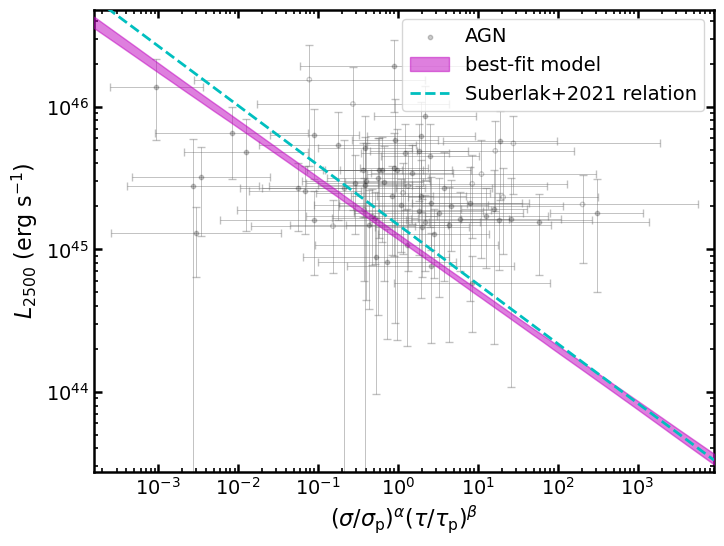

(153     0.794491
 246     1.080144
 277    -0.247978
 279    -0.060154
 487     0.403702
           ...   
 7530    0.568324
 7609   -0.146481
 7741    1.222228
 7775    0.661152
 7792    0.662863
 Name: apparent_mag_2500, Length: 72, dtype: float64,
 array([0.54067161, 0.47012203, 0.46837897, 0.50671014, 0.75944713,
        0.4909627 , 0.58885111, 0.69097764, 0.64816904, 0.35948794,
        0.44747862, 0.59289547, 0.38532769, 0.50733408, 0.39971049,
        0.41768504, 0.34096389, 0.37280178, 0.45921595, 0.55298942,
        0.52643574, 0.31177949, 0.57078133, 0.35335912, 0.33352738,
        0.47602685, 0.38110859, 0.51869156, 0.38782707, 0.52944973,
        0.36943057, 0.45684483, 0.2997345 , 0.40645185, 0.4853832 ,
        0.50986685, 0.45774023, 0.34538049, 0.37200778, 0.30925681,
        0.65133931, 0.39780385, 0.38934897, 0.33932317, 0.51386336,
        0.51692303, 0.43574671, 0.35496858, 0.4723867 , 0.36204388,
        0.54142379, 0.52530569, 0.36250003, 0.48608717, 0.4120252 ,


In [81]:
plot_predicted_L2500_vs_sigmahat(
    flat_samples, d, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=True, debias=False, dms=None,
    show_residuals=False
)

In [88]:
cosmo_model = "Flatw0waCDM"
print(prefix)
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model}_joint_{speed}.save",
                    only_sna=False, speed=speed, skip_plots=True)
#_, flat_samples_w0wa, model_labels_w0wa, dmag_corr_w0wa, _, _, _ = debiased_residuals_w0wa = r
_, flat_samples, model_labels, dmag_corr, _, _, _, _ = r

oct5a_preview_fhost1_oct3g_zspecoct4c_test_zin
Running sampling with 9 parameters for cosmological model: Flatw0waCDM
object_id for m2500 > 25: ['022313.00-001047.8' '014135.94+010904.1']
Best alpha selected by CV: 0.07054802310718646
a (slope on mag_i)      = 1.063752 ± 0.003273
b (slope on alpha)      = 1.237191 ± 0.005788
d (quad term on mag_i)  = -0.005979 ± 0.001427
c_pivot (at pivots)     = 22.040003 ± 0.003366
c (intercept)           = 4.750276
R^2                     = 0.9232
Scatter (σ)             = 0.272 mag
Using mag range: 16.00 to 28.00
Using z range: 0.13 to 4.88
log tau UV RF mean: 2.7293
log tau UV RF pivot (weighted): 2.6382
log sigma0 mean: -0.7520
log sigma0 pivot (weighted): -0.7504
alpha_nu mean: -0.1448
alpha_nu pivot (weighted): nan
z mean: 1.684, calculated z pivot: 1.585
Checkpoint file: results/dynesty_checkpoint/test/dynesty_checkpoint_Flatw0waCDM_joint_test.save
Starting Hubble Fit with 9266 AGNs and 1657 SNes...


/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/oct5a_preview_fhost1_oct3g_zspecoct4c_test_zin/dynesty_checkpoint_Flatw0waCDM_joint_test.save

Bayesian evidence logZ = 2620.31 ± 0.54

Highest-weight (posterior) sample:
  idx: 2998
  logl: 2648.576975036185
  weight: 0.002042489270183976
  (preview) integrals[:10]: [0.27062773 0.04962834 0.38031284 0.24999986 0.3226059  0.16833427
 0.14824157 0.16175747 0.25212573 0.29869614]

Dynesty results stats:
  samples shape: (3847, 9)
  blobs shape: (3847, 2, 9266)
  weights max: 0.002042489270183976
  effective samples (ESS): 761.6127022733651
  resampled samples shape: (3847, 9)
  resampled blobs shape: (3847, 2, 9266)

Median parameters (equal-weight posterior):
[-19.24510634 -22.54945782   6.75140679  -2.60474372  -0.17507337
  72.70197524   0.54868933  -0.56561263 -13.22858678]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8393954348253472
          M0_sn: -19.2451 (+0.0319, -0.

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:808: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


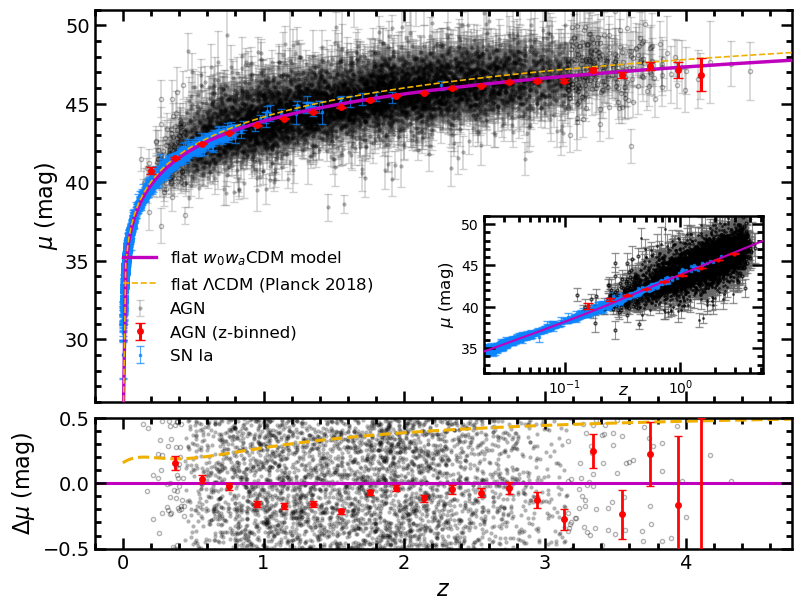

Residuals saved to plots/hubble/test/residuals.csv
Outliers (|residuals| > 5) saved to plots/hubble/test/outliers.csv


In [90]:
residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, 'Flatw0waCDM', z_pivot_agn,
            plot_path="plots/hubble/test", show_binned_agn=True,
            debias=True, dms=dmag_corr, show=True, completeness=True, verbose=False,
            cosmo_model_samples={})


In [94]:
df_agn['residuals'] = residuals
d = df_agn[df_agn['log_tau_UV_RF'] < 2]
d.sort_values('residuals', ascending=True)[['object_id', 'residuals', 'log_tau_UV_RF', 'suffix']][:10]

,object_id,residuals,log_tau_UV_RF,suffix
5650,1439949,-6.443946,1.897152,job5894
4617,1430667,-5.315641,1.685999,job4802
7730,1451784,-5.022900,1.997665,job8059
5175,1435828,-4.986673,1.889205,job5391
4288,1427630,-4.784103,1.768740,job4456
6340,1445653,-4.699950,1.693190,job6619
4610,1430593,-4.657031,1.707871,job4795
1783,1404564,-4.559416,1.889736,job1853
8529,1462490,-4.541971,1.964743,job8882
4691,1431320,-4.457366,1.580841,job4881


In [41]:
residuals_path = f'plots/hubble/{prefix}/Flatw0waCDM_joint_dev/residuals.csv'
df_residuals = pd.read_csv(residuals_path, dtype={'object_id': str})

# Convert 'object_id' columns to string before merging
df_residuals['object_id'] = df_residuals['object_id'].astype(str)
df_agn['object_id'] = df_agn['object_id'].astype(str)

# Merge df and df_agn on 'object_id'
df_matched = df_residuals.merge(df_agn, on='object_id', suffixes=('_df', '_agn'))

df_matched_cut = df_matched[df_matched['residuals'] > 5].sort_values('residuals', ascending=False)
df_matched_cut[['object_id', 'z_df', 'residuals', 'log_sigma_UV', 'log_tau_UV_RF', 'log_sigma_band_g_err']]
len(df_matched_cut)


18

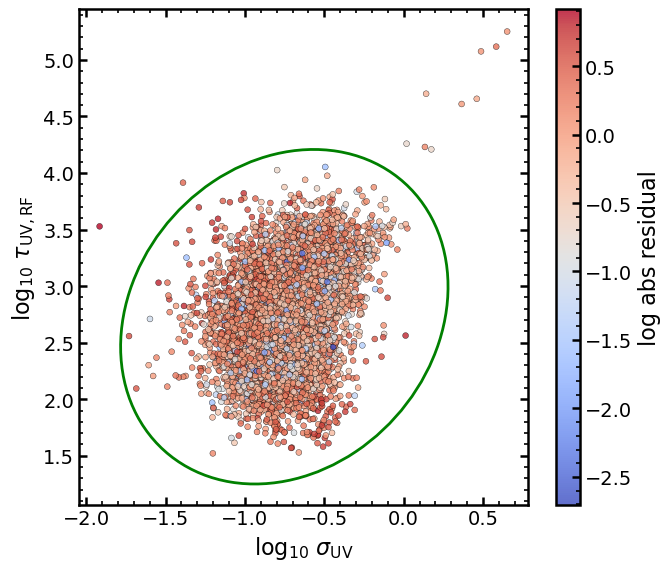

In [117]:
from matplotlib.patches import Ellipse

plt.figure(figsize=(7,6))
sc = plt.scatter(
    df_agn['log_sigma_UV'], df_agn['log_tau_UV_RF'],
    c=df_agn['log_residuals'], cmap='coolwarm', s=18, alpha=0.8, edgecolor='k', linewidth=0.3
)
cbar = plt.colorbar(sc)
cbar.set_label('log abs residual')
plt.xlabel(r'$\log_{10}\,\sigma_{\rm UV}$')
plt.ylabel(r'$\log_{10}\,\tau_{\rm UV,RF}$')

log_sigma_UV_pivot = np.mean(df_agn['log_sigma_UV'])
log_tau_UV_RF_pivot = np.mean(df_agn['log_tau_UV_RF'])

# Draw an ellipse centered at (-0.75, 2)
ellipse = Ellipse(xy=(log_sigma_UV_pivot, log_tau_UV_RF_pivot), width=3, height=2, angle=77, edgecolor='green', facecolor='none', lw=2)
plt.gca().add_patch(ellipse)

plt.tight_layout()
plt.show()
#width=2.441, height=1.126, angle=77.7 deg

In [ ]:
#df_matched[df_matched['z_df'] < 0.5][['object_id', 'z_df', 'residuals']].sort_values('residuals', ascending=False)


,object_id,z_df,residuals
0,1413687,0.488448,8.318544
1,1417406,0.377382,8.309452
7,1445627,0.459647,5.634834
14,1418141,0.266692,5.174553
21,1465615,0.414828,4.781122
...,...,...,...
8378,1421696,0.436747,-1.890282
8413,1402558,0.386472,-1.952636
8483,1422650,0.430934,-2.135914
8493,1420949,0.468651,-2.202758


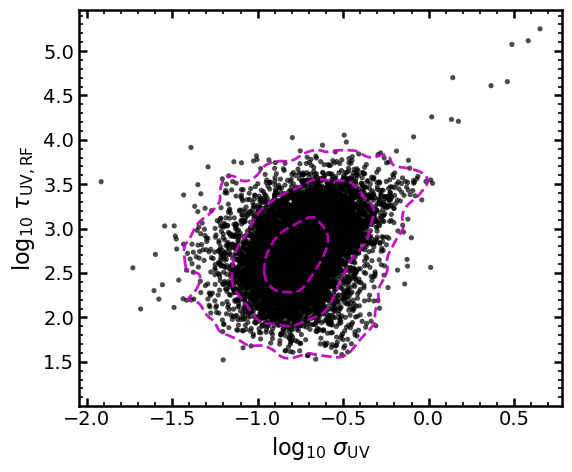

In [19]:
import numpy as np
from scipy.stats import gaussian_kde, chi2
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# --- scatter: light blue points ---
x = df_agn['log_sigma_UV'].to_numpy()
y = df_agn['log_tau_UV_RF'].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

plt.scatter(
    x, y,
    c='k',
    alpha=0.7,
    s=14,
    edgecolors='none'
)

# --- KDE grid with generous padding to avoid open (clipped) outer contours ---
# (Use very wide quantiles + extra pad to keep 3σ closed.)
q_lo, q_hi = 0.001, 0.999
xq0, xq1 = np.quantile(x, [q_lo, q_hi])
yq0, yq1 = np.quantile(y, [q_lo, q_hi])
pad_x = 0.25 * (xq1 - xq0)
pad_y = 0.25 * (yq1 - yq0)
xmin, xmax = xq0 - pad_x, xq1 + pad_x
ymin, ymax = yq0 - pad_y, yq1 + pad_y

xx, yy = np.mgrid[xmin:xmax:256j, ymin:ymax:256j]
kde = gaussian_kde(np.vstack([x, y]))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# Small visual smoothing helps remove jagged edges without changing the mass ranking
zz = gaussian_filter(zz, sigma=0.8)

# --- Highest-density (HPD) contour levels for 1, 2, 3 "sigma" in 2D ---
# In 2D, mass inside radius r is chi2.cdf(r^2, df=2).
sigma = np.array([1.0, 2.0, 3.0])
probs = chi2.cdf(sigma**2, df=2)  # ≈ [0.3935, 0.8647, 0.9889]

z_sort = np.sort(zz.ravel())[::-1]
cdf = np.cumsum(z_sort) / z_sort.sum()
thr = np.interp(probs, cdf, z_sort)

# Matplotlib expects increasing levels (low->high density) i.e., [3σ, 2σ, 1σ]
levels = np.sort(thr)
# Ensure strict monotonicity (avoids "Non-increasing" due to ties)
levels = np.maximum.accumulate(np.nextafter(levels, np.inf))

# Style mapping for ascending levels: [3σ, 2σ, 1σ]
colors = ['m', 'm', 'm']      # 3σ black, 2σ light gray, 1σ dark gray
linestyles = ['--', '--', '--']             # 3σ dashed, 2σ solid, 1σ solid
linewidths = [2, 2, 2.0]

plt.contour(xx, yy, zz, levels=levels, alpha=0.9,
            colors=colors, linestyles=linestyles, linewidths=linewidths)

plt.xlabel(r'$\log_{10}\,\sigma_{\rm UV}$')
plt.ylabel(r'$\log_{10}\,\tau_{\rm UV,RF}$')
#plt.title(r'$\log_{10}\,\tau_{\rm UV,RF}$ vs $\log_{10}\,\sigma_{\rm UV}$')
plt.tight_layout()
plt.show()


width=2.441, height=1.126, angle=77.7 deg


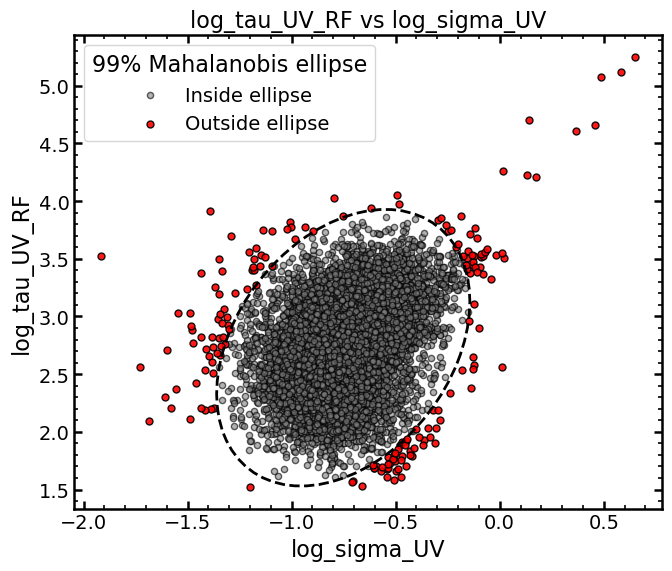

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

# --- Data matrix (drop NaNs) ---
X = df_agn[['log_sigma_UV','log_tau_UV_RF']].dropna().values
x = X[:,0]; y = X[:,1]

# --- Mahalanobis ellipse params ---
alpha = 0.99  # confidence level for the kept "bulk" (change to 0.95 if you want tighter)
mean = X.mean(axis=0)
cov  = np.cov(X, rowvar=False)
cov_inv = np.linalg.inv(cov)
chi2_thr = chi2.ppf(alpha, df=2)  # threshold on squared Mahalanobis distance

# distances
dX = X - mean
d2 = np.einsum('ij,jk,ik->i', dX, cov_inv, dX)  # squared Mahalanobis distance
inside = d2 <= chi2_thr
outside = ~inside

# --- Ellipse geometry (principal axes of covariance scaled to chosen level) ---
eigvals, eigvecs = np.linalg.eigh(cov)        # ascending order
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:,order]

scale = np.sqrt(chi2_thr)
width, height = 2*scale*np.sqrt(eigvals)      # full axis lengths
angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))

print(f"width={width:.3f}, height={height:.3f}, angle={angle:.1f} deg")

# --- Plot ---
plt.figure(figsize=(7,6))

plt.scatter(x[inside], y[inside],
            c='gray', alpha=0.6, edgecolor='k', s=20, label='Inside ellipse')

plt.scatter(x[outside], y[outside],
            c='red', alpha=0.9, edgecolor='k', s=25, label='Outside ellipse')

ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
              fill=False, lw=2.0, ls='--', edgecolor='black', zorder=3)
plt.gca().add_patch(ell)

plt.xlabel('log_sigma_UV')
plt.ylabel('log_tau_UV_RF')
plt.title('log_tau_UV_RF vs log_sigma_UV')

# clean legend
plt.legend(title=f'{int(alpha*100)}% Mahalanobis ellipse', frameon=True)
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd

# --- Build mask from previous code ---
df_vals = df_agn[['log_sigma_UV','log_tau_UV_RF']].dropna()
X = df_vals.values
mean = X.mean(axis=0)
cov  = np.cov(X, rowvar=False)
cov_inv = np.linalg.inv(cov)

from scipy.stats import chi2
alpha = 0.99
chi2_thr = chi2.ppf(alpha, df=2)

dX = X - mean
d2 = np.einsum('ij,jk,ik->i', dX, cov_inv, dX)
inside = d2 <= chi2_thr
outside = ~inside

# --- Attach mask back to df_agn ---
mask_series = pd.Series(inside, index=df_vals.index)
df_agn['inside_ellipse'] = mask_series.reindex(df_agn.index, fill_value=False)

# --- Save outliers (outside ellipse) ---
df_outside = df_agn.loc[~df_agn['inside_ellipse']]
foutside_path = f'plots/hubble/{prefix}/Flatw0waCDM_joint_dev/sigma_tau_outliers.csv'
df_outside[['object_id', 'z']].to_csv(foutside_path, index=False)
print(f"Saved {len(df_outside)} outliers to {foutside_path}")


Saved 157 outliers to plots/hubble/sept29_lmc4_fhost0.01_dev_all/Flatw0waCDM_joint_dev/sigma_tau_outliers.csv


In [78]:
df_agn[df_agn['log_sigma_UV'] < -1.75][['object_id', 'log_sigma_UV', 'log_tau_UV_RF']]

,object_id,log_sigma_UV,log_tau_UV_RF
3796,1420329,-1.786755,2.310777


In [4]:

cosmo_model_w0wa = "Flatw0waCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_w0wa, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model_w0wa}_joint_{speed}.save",
                    only_sna=False, speed=speed)
_, flat_samples_w0wa, model_labels_w0wa, dmag_corr_w0wa, _, _, debiased_residuals_w0wa = r

Running sampling with 9 parameters for cosmological model: Flatw0waCDM
object_id for m2500 > 25: ['024629.37+000735.3' '011911.24-001112.0']
Best alpha selected by CV: 0.0001
a (slope on mag_i)      = 1.046578 ± 0.003346
b (slope on alpha)      = 1.217357 ± 0.006396
d (quad term on mag_i)  = 0.013534 ± 0.001759
c_pivot (at pivots)     = 22.430897 ± 0.003199
c (intercept)           = -3.101976
R^2                     = 0.8951
Scatter (σ)             = 0.296 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
log tau UV RF mean: 2.8078
log tau UV RF pivot (weighted): 2.5739
log sigma0 mean: -0.6592
log sigma0 pivot (weighted): -0.6833
alpha_nu mean: -0.7858
alpha_nu pivot (weighted): nan
z mean: 1.589, calculated z pivot: 1.496
Checkpoint file: results/dynesty_checkpoint/dynesty_checkpoint_Flatw0waCDM_joint_production.save
Starting Hubble Fit with 12185 AGNs and 1657 SNes...


/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept19_sep8chisq_13k/dynesty_checkpoint_Flatw0waCDM_joint_production.save

Bayesian evidence logZ = -1358.70 ± 0.24

Highest-weight (posterior) sample:
  idx: 14580
  logl: -1331.178802474431
  weight: 0.00039915618275356506
  (preview) integrals[:10]: [0.41699684 0.46212277 0.17716648 0.4627847  0.25299121 0.60644655
 0.33635118 0.54661617 0.28455611 0.23995735]

Dynesty results stats:
  samples shape: (18660, 9)
  blobs shape: (18660, 2, 12185)
  weights max: 0.00039915618275356506
  effective samples (ESS): 3757.6500046457927
  resampled samples shape: (18660, 9)
  resampled blobs shape: (18660, 2, 12185)

Median parameters (equal-weight posterior):
[-19.24244634 -21.94270847   7.04665858  -3.12241814  -0.19214753
  72.68408276   0.57695675  -0.47237168 -17.83848575]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8251851204288057
Saving plots to  plots/hubble//Flatw0waCDM_jo

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:1027: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  num_panels = num_rows * num_cols


Plotting Hubble diagram...


<string>:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Residuals saved to plots/hubble//Flatw0waCDM_joint_production/residuals.csv


<string>:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4 (sorted by residual, largest last):
	z: 2.76 | object_id: 1390664 | npca_qso: 0 | SDSS: 024328.86+003831.0 | RA: 40.87026 | DEC: 0.64196 | Residual: -5.5
	z: 1.65 | object_id: 1440703 | npca_qso: 0 | SDSS: 001342.45-002412.6 | RA: 3.42689 | DEC: -0.40351 | Residual: -4.6
	z: 0.83 | object_id: 1407814 | npca_qso: 1 | SDSS: 015500.27+004951.4 | RA: 28.75113 | DEC: 0.83096 | Residual: -4.5
	z: 1.07 | object_id: 1417953 | npca_qso: 0 | SDSS: 012528.84-000555.9 | RA: 21.37019 | DEC: -0.09888 | Residual: -4.4
	z: 0.27 | object_id: 1413536 | npca_qso: 1 | SDSS: 013809.54-010920.2 | RA: 24.53975 | DEC: -1.15563 | Residual: -4.3
	z: 0.19 | object_id: 1434162 | npca_qso: 2 | SDSS: 003511.48-004918.0 | RA: 8.79785 | DEC: -0.82167 | Residual: -4.3
	z: 1.39 | object_id: 1431736 | npca_qso: 2 | SDSS: 004222.09-003742.7 | RA: 10.59206 | DEC: -0.62854 | Residual: -4.3
	z: 2.86 | object_id: 1451784 | npca_qso: 2 | SD

[-0.26974147 -0.54510513 -0.99380543 ...  0.03886741  0.45146891
  0.21541936]


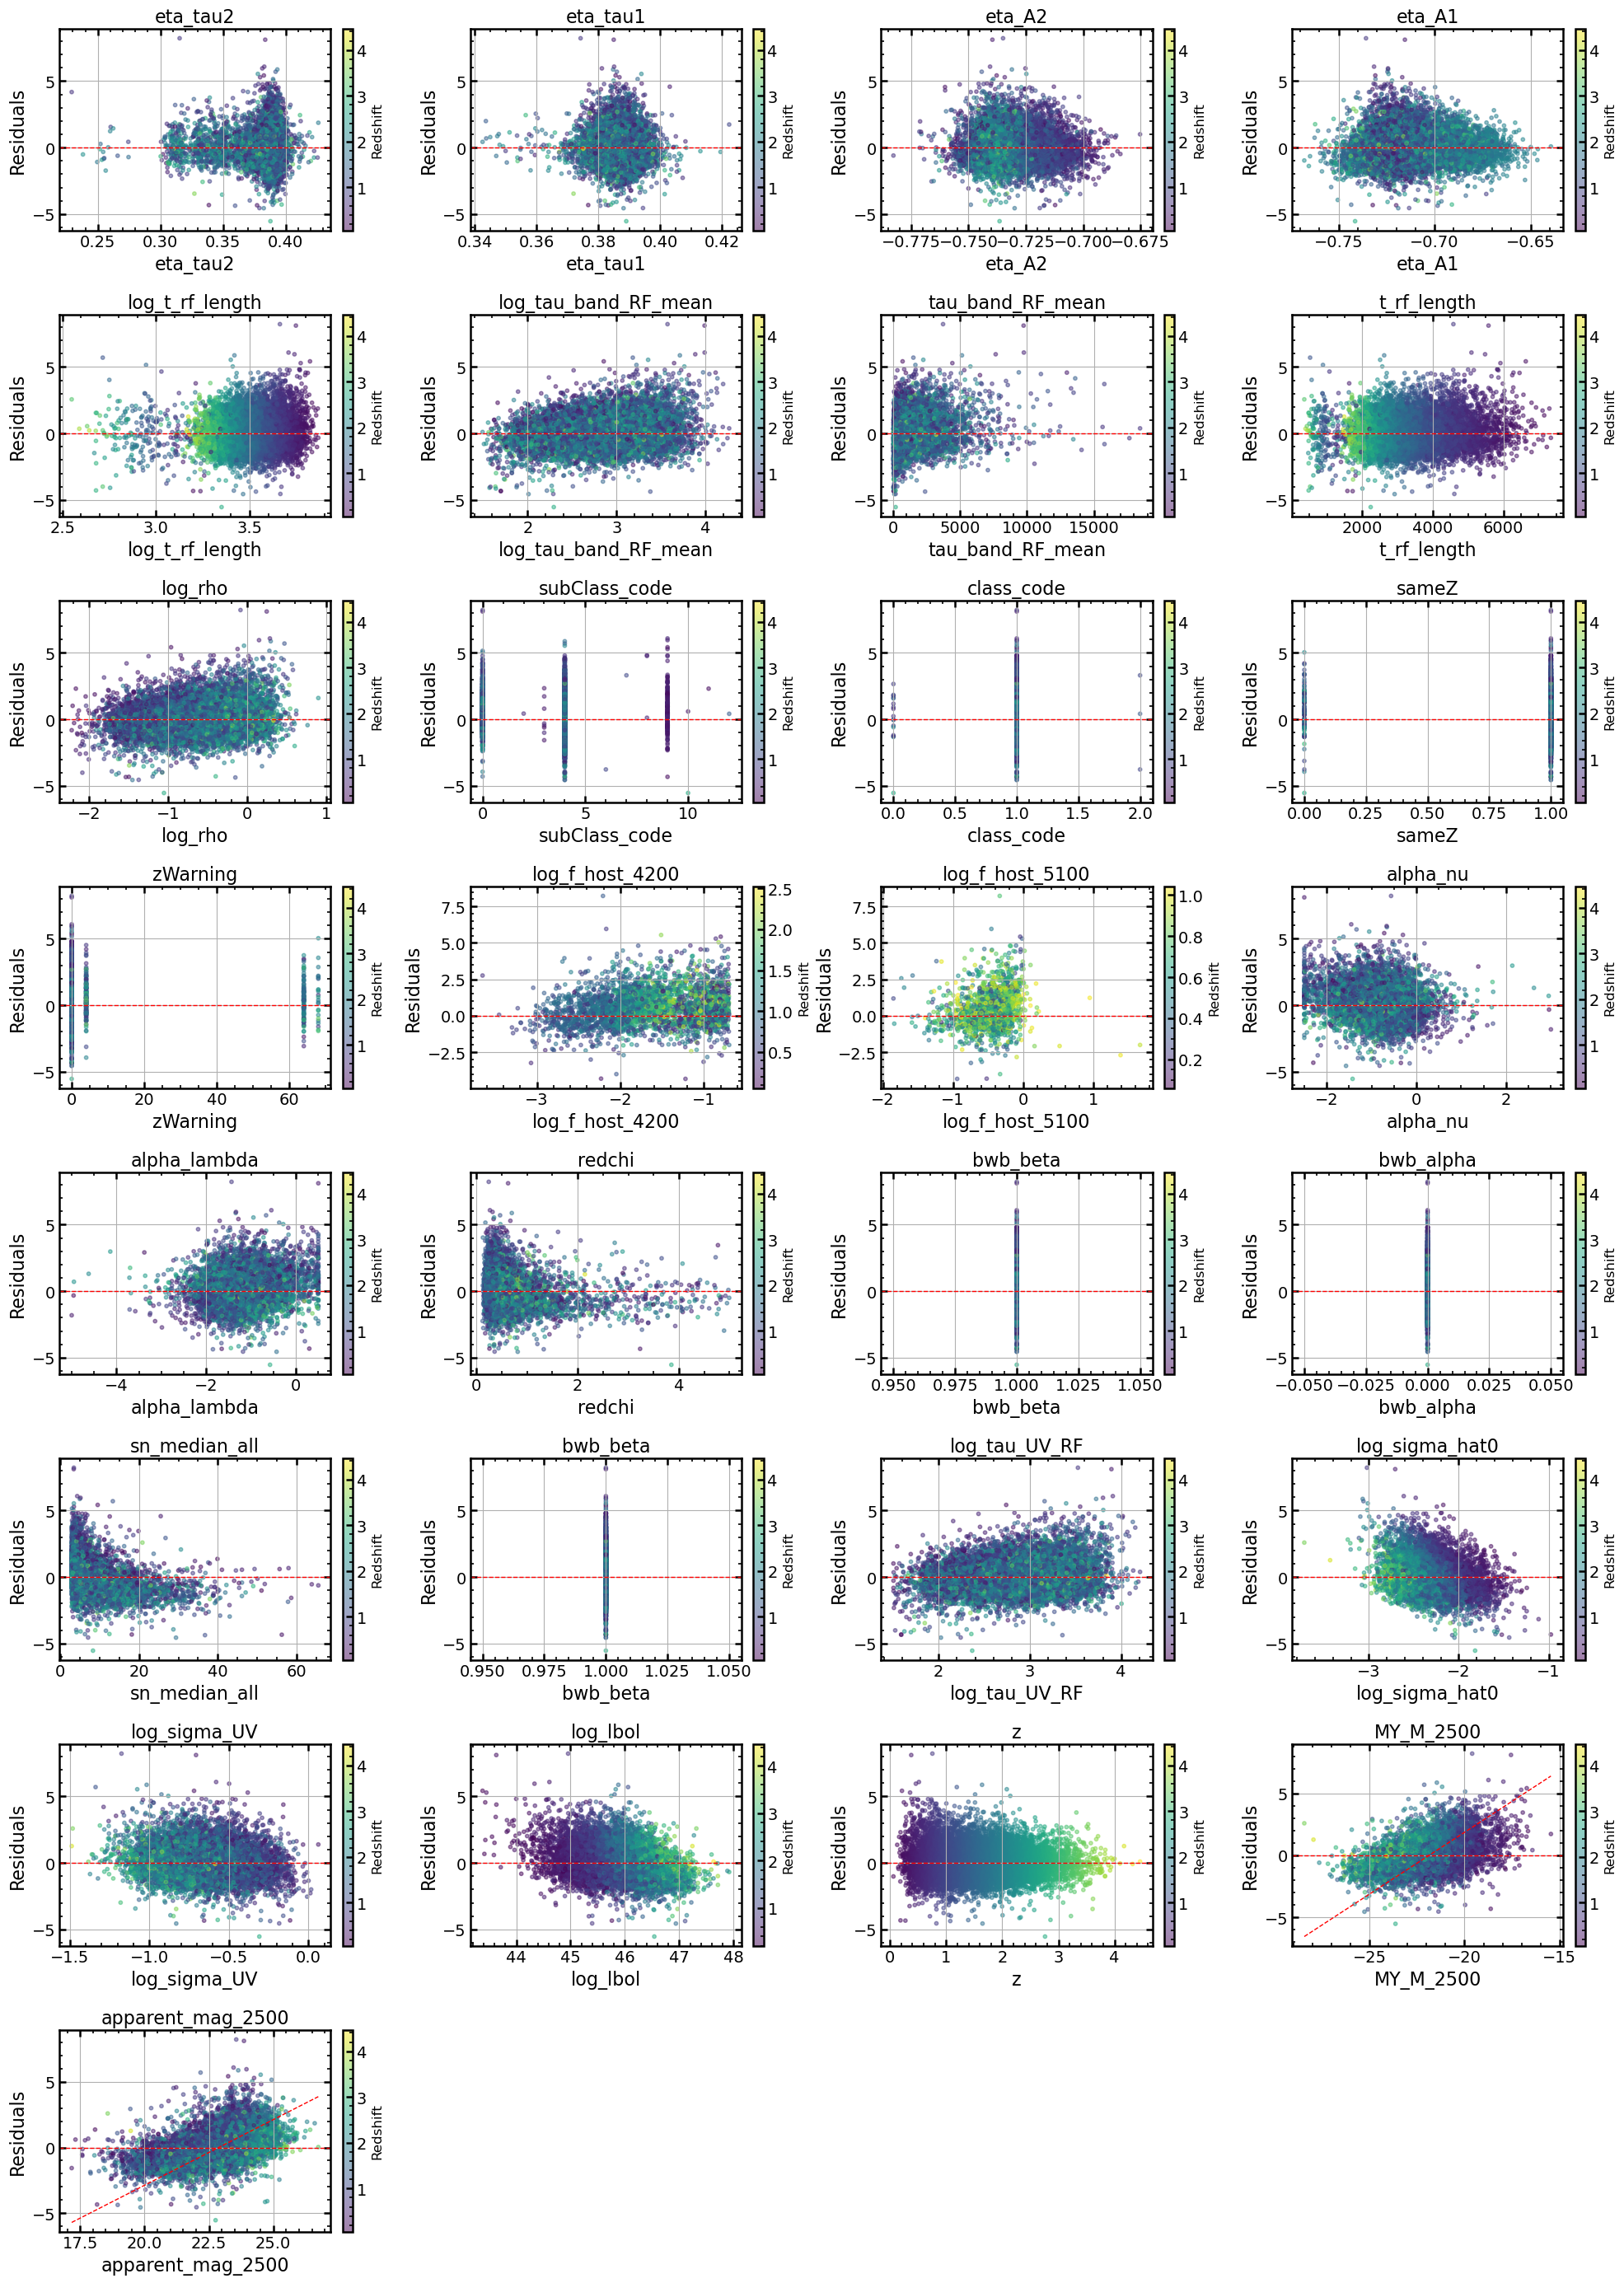

In [17]:
plot_full_residuals(df_agn, debiased_residuals_w0wa, flat_samples_w0wa, cosmo_model_w0wa, 0, debias=True, dms=dmag_corr_w0wa, plot_path='plots/hubble', show=True)

In [ ]:

cosmo_model_w = "FlatwCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_w, completeness=True, use_full_cov=True, 
                     resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model_w}_joint_{speed}.save",
                    only_sna=False, speed=speed)
_, flat_samples_w, _, dmag_corr, _, _, debiased_residuals_w = r

Running sampling with 8 parameters for cosmological model: FlatwCDM
object_id for m2500 > 25: ['024629.37+000735.3']
Best alpha selected by CV: 0.0001
a (slope on mag_i)      = 1.048097 ± 0.006170
b (slope on alpha)      = 1.216196 ± 0.011838
d (quad term on mag_i)  = 0.016309 ± 0.003252
c_pivot (at pivots)     = 22.409202 ± 0.005976
c (intercept)           = -4.273166
R^2                     = 0.8953
Scatter (σ)             = 0.300 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
mag centers: [16.14 16.42 16.7  16.98 17.26 17.54 17.82 18.1  18.38 18.66 18.94 19.22
 19.5  19.78 20.06 20.34 20.62 20.9  21.18 21.46 21.74 22.02 22.3  22.58
 22.86 23.14 23.42 23.7  23.98 24.26 24.54 24.82 25.1  25.38 25.66 25.94
 26.22 26.5  26.78 27.06 27.34 27.62 27.9  28.18 28.46 28.74 29.02 29.3
 29.58 29.86]
log tau UV RF mean: 2.8119
log tau UV RF pivot (weighted): 2.5699
log sigma0 mean: -0.6620
log sigma0 pivot (weighted): -0.6856
alpha_nu mean: -0.7884
alpha_nu pivot (weighted): nan

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept19_sep8chisq_4k/dynesty_checkpoint_FlatwCDM_joint_production.save

Bayesian evidence logZ = 4755.38 ± 0.22

Highest-weight (posterior) sample:
  idx: 12564
  logl: 4778.849087267037
  weight: 0.00038802778298869807
  (preview) integrals[:10]: [0.1238134  0.1386183  0.08443869 0.06859757 0.09837811 0.14915133
 0.0579019  0.10750716 0.09602357 0.11218172]

Dynesty results stats:
  samples shape: (16614, 8)
  blobs shape: (16614, 2, 3562)
  weights max: 0.00038802778298869807
  effective samples (ESS): 3677.5058513934723
  resampled samples shape: (16614, 8)
  resampled blobs shape: (16614, 2, 3562)

Median parameters (equal-weight posterior):
[-19.2437823  -22.03674561   7.20105472  -3.29537037  -0.17253552
  73.66612732   0.41688793  -1.24845763]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8415284006088787
Saving plots to  plots/hubble//FlatwCDM_joint_production
Plotting 

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.49 | object_id: 1395787 | SDSS: 022914.13+010741.7 | RA: 37.30891 | DEC: 1.12826 | Residual: 4.7
	z: 1.19 | object_id: 1398455 | SDSS: 022159.81-005243.1 | RA: 35.49923 | DEC: -0.87864 | Residual: 5.6
	z: 1.65 | object_id: 1398944 | SDSS: 022045.29+011252.8 | RA: 35.18873 | DEC: 1.21468 | Residual: 4.0
	z: 0.44 | object_id: 1400643 | SDSS: 021605.09-001019.0 | RA: 34.02121 | DEC: -0.17194 | Residual: 4.4
	z: 0.84 | object_id: 1406881 | SDSS: 015802.36+002917.3 | RA: 29.50986 | DEC: 0.48816 | Residual: 4.1
	z: 0.41 | object_id: 1410524 | SDSS: 014638.32-004438.1 | RA: 26.65970 | DEC: -0.74393 | Residual: 4.6
	z: 0.27 | object_id: 1413536 | SDSS: 013809.54-010920.2 | RA: 24.53975 | DEC: -1.15563 | Residual: -4.2
	z: 1.98 | object_id: 1418942 | SDSS: 012223.42+004629.8 | RA: 20.59758 | DEC: 0.77497 | Residual: 4.6
	z: 0.74 | object_id: 1420387 | SDSS: 011812.12-010441.5 | RA: 19.55054 | DEC: -1.0

In [ ]:

cosmo_model_lambda = "FlatLambdaCDM"
r = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    cosmo_model_lambda, completeness=True, use_full_cov=True, 
                    resume=f"results/dynesty_checkpoint/{prefix}/dynesty_checkpoint_{cosmo_model_lambda}_joint_{speed}.save",
                    only_sna=False, speed=speed)
_, flat_samples_lambda, _, _, _, _, debiased_residuals_lambda = r

Running sampling with 7 parameters for cosmological model: FlatLambdaCDM
object_id for m2500 > 25: ['024629.37+000735.3']
Best alpha selected by CV: 0.0001
a (slope on mag_i)      = 1.048097 ± 0.006170
b (slope on alpha)      = 1.216196 ± 0.011838
d (quad term on mag_i)  = 0.016309 ± 0.003252
c_pivot (at pivots)     = 22.409202 ± 0.005976
c (intercept)           = -4.273166
R^2                     = 0.8953
Scatter (σ)             = 0.300 mag
Using mag range: 16.00 to 30.00
Using z range: 0.13 to 4.88
mag centers: [16.14 16.42 16.7  16.98 17.26 17.54 17.82 18.1  18.38 18.66 18.94 19.22
 19.5  19.78 20.06 20.34 20.62 20.9  21.18 21.46 21.74 22.02 22.3  22.58
 22.86 23.14 23.42 23.7  23.98 24.26 24.54 24.82 25.1  25.38 25.66 25.94
 26.22 26.5  26.78 27.06 27.34 27.62 27.9  28.18 28.46 28.74 29.02 29.3
 29.58 29.86]
log tau UV RF mean: 2.8119
log tau UV RF pivot (weighted): 2.5699
log sigma0 mean: -0.6620
log sigma0 pivot (weighted): -0.6856
alpha_nu mean: -0.7884
alpha_nu pivot (weighted)

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/sept19_sep8chisq_4k/dynesty_checkpoint_FlatLambdaCDM_joint_production.save

Bayesian evidence logZ = 4756.20 ± 0.22

Highest-weight (posterior) sample:
  idx: 11855
  logl: 4778.351136213723
  weight: 0.0004314080610032329
  (preview) integrals[:10]: [0.12029702 0.13566578 0.08108219 0.06438567 0.09654083 0.1435266
 0.05312624 0.10151918 0.09356814 0.10936957]

Dynesty results stats:
  samples shape: (15536, 7)
  blobs shape: (15536, 2, 3562)
  weights max: 0.0004314080610032329
  effective samples (ESS): 3420.6654005676137
  resampled samples shape: (15536, 7)
  resampled blobs shape: (15536, 2, 3562)

Median parameters (equal-weight posterior):
[-19.24164048 -22.05926823   7.30962433  -3.3378921   -0.1669507
  73.42054544   0.3484523 ]
1 sigma scatter on HD (magnitudes)
  sigma_intrinsic: 0.8462413337430826
Saving plots to  plots/hubble//FlatLambdaCDM_joint_production
Plotting full dy

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:686: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.49 | object_id: 1395787 | SDSS: 022914.13+010741.7 | RA: 37.30891 | DEC: 1.12826 | Residual: 4.8
	z: 1.19 | object_id: 1398455 | SDSS: 022159.81-005243.1 | RA: 35.49923 | DEC: -0.87864 | Residual: 5.7
	z: 1.65 | object_id: 1398944 | SDSS: 022045.29+011252.8 | RA: 35.18873 | DEC: 1.21468 | Residual: 4.0
	z: 0.44 | object_id: 1400643 | SDSS: 021605.09-001019.0 | RA: 34.02121 | DEC: -0.17194 | Residual: 4.5
	z: 0.84 | object_id: 1406881 | SDSS: 015802.36+002917.3 | RA: 29.50986 | DEC: 0.48816 | Residual: 4.1
	z: 0.41 | object_id: 1410524 | SDSS: 014638.32-004438.1 | RA: 26.65970 | DEC: -0.74393 | Residual: 4.7
	z: 0.27 | object_id: 1413536 | SDSS: 013809.54-010920.2 | RA: 24.53975 | DEC: -1.15563 | Residual: -4.1
	z: 1.98 | object_id: 1418942 | SDSS: 012223.42+004629.8 | RA: 20.59758 | DEC: 0.77497 | Residual: 4.6
	z: 0.74 | object_id: 1420387 | SDSS: 011812.12-010441.5 | RA: 19.55054 | DEC: -1.0

In [ ]:
cosmo_model_samples = {
    "Flatw0waCDM": flat_samples_w0wa,
    "FlatwCDM": flat_samples_w,
    "FlatLambdaCDM": flat_samples_lambda
}
cosmo_model_residuals = {
    "Flatw0waCDM": debiased_residuals_w0wa,
    "FlatwCDM": debiased_residuals_w,
    "FlatLambdaCDM": debiased_residuals_lambda
}

/tmp/ipykernel_487955/3892376919.py:184: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)
/tmp/ipykernel_487955/3892376919.py:184: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)


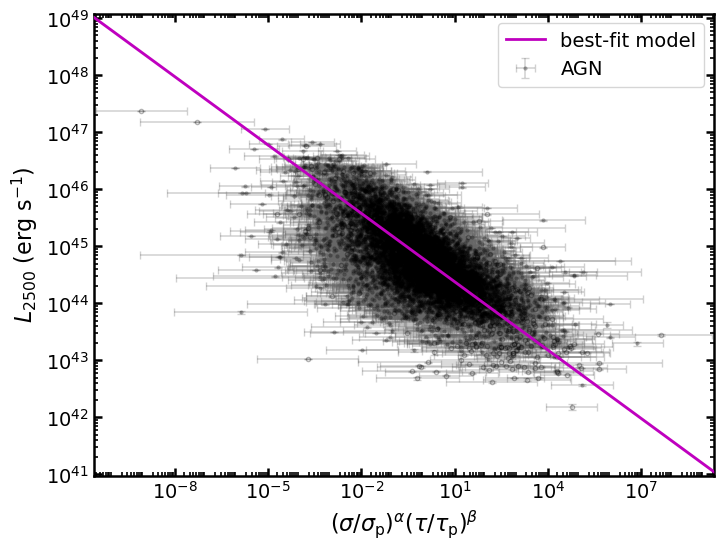

In [34]:
def plot_predicted_L2500_vs_sigmahat(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, debias=True, dms=None,
    show_residuals=False
):
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Indices & parameter names ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    def compute_xlog_and_err(params_arr, obs_arr, err_arr, pivots_array):
        M0_agn = params_arr[agn_model_pidx["M0_agn"]]
        predicted_M = M_model_agn(params_arr, obs_arr, pivots_array) - M0_agn
        x_log = predicted_M

        predited_M_err = M_model_agn_err(params_arr, obs_arr, err_arr, pivots_array)
        x_log_err = predited_M_err

        return x_log, x_log_err

    # --- Posterior medians (for cosmology & placing data in x) ---
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=results['H0'], Om0=results['Om0'], wp=results['wp'], wa=results['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'], wa=results['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=results['H0'], Om0=results['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # --- y-data: log10 L_2500 (with optional debias) ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        actual_M2500 = (d['apparent_mag_2500'] - dm_interp(pts)) - cosmo.distmod(d['z']).value
    else:
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90.0)

    # y measurement uncertainty from apparent magnitudes (propagated into log10 L)
    y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))

    # --- x for data (full predictor) ---
    median_params_arr = agn_model_pack_params(results)
    x_log_data, x_log_err_data = compute_xlog_and_err(median_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_data = 10**x_log_data
    x_lower = 10**(x_log_data - x_log_err_data)
    x_upper = 10**(x_log_data + x_log_err_data)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # --- Grid for model curves/band ---
    x_lo = np.percentile(x_log_data - x_log_err_data, 0) - 0.05
    x_hi = np.percentile(x_log_data + x_log_err_data, 100) + 0.05
    x_log_grid = np.linspace(x_lo, x_hi, 200)
    x_grid = 10**x_log_grid

    # --- Predict logL on grid for each posterior sample (we'll only use quantiles + median line) ---
    ylog_grid_by_sample = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        aparr = agn_model_pack_params(sample_params)
        M0 = aparr[agn_model_pidx["M0_agn"]]
        b = -0.4 * (M0 - 90.0)
        ylog_grid_by_sample.append(b + (-0.4) * x_log_grid)

    ylog_grid_by_sample = np.asarray(ylog_grid_by_sample)  # (nsamp, ngrid)
    ylog_med  = np.median(ylog_grid_by_sample, axis=0)
    ylog_low  = np.percentile(ylog_grid_by_sample, 16, axis=0)
    ylog_high = np.percentile(ylog_grid_by_sample, 84, axis=0)
    y_hi = np.max(ylog_high) + 0.05
    y_lo = np.min(ylog_low)  - 0.05

    # --- Residuals vs median model (log space) ---
    f_med  = interp1d(x_log_grid, ylog_med,  bounds_error=False, fill_value='extrapolate')
    f_low  = interp1d(x_log_grid, ylog_low,  bounds_error=False, fill_value='extrapolate')
    f_high = interp1d(x_log_grid, ylog_high, bounds_error=False, fill_value='extrapolate')

    model_logL_at_data = f_med(x_log_data)
    residuals = actual_logL2500 - model_logL_at_data

    # Error budget in log space for residuals: model spread + x-prop + mag error
    obs_err = 0.5 * (f_high(x_log_data) - f_low(x_log_data))
    propagated_err = 0.4 * np.abs(x_log_err_data)
    total_err = np.sqrt(obs_err**2 + propagated_err**2 + y_log_meas_err**2)

    # --- Figure scaffold ---
    color = 'm'
    if show_residuals:
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_res = None

    # --- Data with x & y error bars (y errors converted to linear space) ---
    key = 'alpha_lambda'
    color_key = d[key] if key in d.columns else np.zeros(len(d))
    yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = d["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # AGN (inside)
    ax.errorbar(
        x_data[mask_in], 10**actual_logL2500[mask_in], xerr=xerr_asym[:, mask_in], yerr=yerr_linear[mask_in],
        fmt='o', linestyle='none', markersize=3,
        mfc="black", mec="none",
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0, label="AGN"
    )
    # AGN (outside, open)
    ax.errorbar(
        x_data[mask_out], 10**actual_logL2500[mask_out], xerr=xerr_asym[:, mask_out], yerr=yerr_linear[mask_out],
        fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
        ecolor="#666666", elinewidth=1.1, zorder=0
    )

    # ax.scatter(
    #     x_data, 10**actual_logL2500,
    #     s=12, c="black", marker="o", edgecolors="none", alpha=0.8, zorder=1, label="AGN"
    # )
    # ax.errorbar(
    #     x_data, 10**actual_logL2500, xerr=xerr_asym, yerr=yerr_linear,
    #     fmt='none', linestyle='none',
    #     ecolor="#666666", elinewidth=1.1,
    #     alpha=0.3, zorder=0
    # )
    # --- Model: one line (median) + 68% band ---
    ax.fill_between(x_grid, 10**ylog_low, 10**ylog_high, color=color, alpha=0.18, zorder=9,)
    ax.plot(x_grid, 10**ylog_med, color=color, lw=2.0, zorder=10, label='best-fit model')

    # --- Axes & labels ---
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim((3e-7, 7e5))
    # ax.set_ylim((7e41, 2e47))
    ax.set_xlim((10**x_lo, 10**x_hi))
    ax.set_ylim((10**y_lo, 10**y_hi))
    
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))


    ax.legend()

    if show_residuals and ax_res is not None:
        sc = ax_res.scatter(x_data, residuals, s=10, alpha=0.7, c=color_key, cmap='bwr',
                            edgecolor='k', lw=0.5, zorder=5)
        cbar = plt.colorbar(sc, ax=ax_res, orientation='vertical'); cbar.set_label(key)
        ax_res.errorbar(x_data, residuals, yerr=total_err,
                        fmt='none', alpha=0.25, lw=1.2, capsize=2.5, capthick=1, color='k', zorder=4)
        ax_res.axhline(0, color=color, linestyle='--', zorder=3)
        ax_res.set_ylabel('Residuals (log)')
        ax_res.set_xlabel(r'$x=\sigma^\alpha\,\tau^\beta\,10^{\gamma\,\mathrm{logistic}(\alpha_\nu)}$')
        ax_res.set_xscale('log')
        ax_res.set_ylim(-2.2, 2.2)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel(r'$(\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')
        plt.setp(ax.get_xticklabels(), visible=True)


    os.makedirs(plot_path, exist_ok=True)
    os.makedirs(os.path.join(plot_path, "pdf"), exist_ok=True)
    if debias:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band_debiased.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)
    else:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band.pdf"), dpi=600)

    if show:
        plt.show()
    plt.close()

plot_predicted_L2500_vs_sigmahat(
    flat_samples_w0wa, df_agn, cosmo_model_w0wa, z_pivot_agn,
    plot_path='plots/hubble', show=True, debias=True, dms=dmag_corr_w0wa,
    show_residuals=False
)

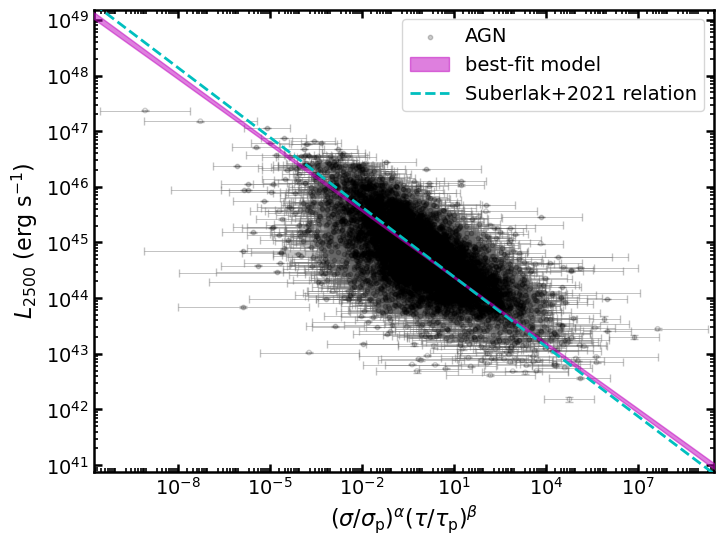

In [105]:
def plot_predicted_L2500_vs_sigmahat(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, debias=True, dms=None,
    show_residuals=False
):
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Indices & parameter names ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    # Helper: posterior median dict
    med_params = {k: np.median(flat_samples[:, param_indices[k]]) for k in model_labels}

    # --- Cosmology from medians (only for placing the *data* on y) ---
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=med_params['H0'], Om0=med_params['Om0'], w0=med_params['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=med_params['H0'], Om0=med_params['Om0'],
                            wp=med_params['wp'], wa=med_params['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=med_params['H0'], Om0=med_params['Om0'],
                            w0=med_params['w0'], wa=med_params['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=med_params['H0'], Om0=med_params['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # --- y-data: log10 L_2500 (with optional de-bias of apparent magnitudes) ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        actual_M2500 = (d['apparent_mag_2500'] - dm_interp(pts)) - cosmo.distmod(d['z']).value
    else:
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = convert_M2500_to_logL2500(actual_M2500)

    # y measurement uncertainty propagated to log10 L
    y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))

    # --- Reference x (built at POSTERIOR-MEDIAN params) ---
    # This is the "common" axis we’ll plot against. It fixes the x definition,
    # then each posterior draw is *refit* onto this axis (slope+intercept).
    med_arr = agn_model_pack_params(med_params)
    M0_med = med_arr[agn_model_pidx["M0_agn"]]
    # predicted_M_ref = (M_model - M0) evaluated at median params → this is the "x in M-space"
    x_log_ref = M_model_agn(med_arr, agn_obs_arr, agn_pivot_arr) - M0_med
    x_ref = 10.0 ** x_log_ref

    # --- x for the plotted points (computed at med params for consistency with x_ref) ---
    x_data = x_ref
    # Propagate x errors from median params (same as before)
    pred_M_err_med = M_model_agn_err(med_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_lower = 10.0 ** (x_log_ref - pred_M_err_med)
    x_upper = 10.0 ** (x_log_ref + pred_M_err_med)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # Center of mass in the *reference* x (we’ll use this for plotting & band widening)
    xcm = np.mean(x_log_ref)
    var_x = np.var(x_log_ref, ddof=1)
    if not np.isfinite(var_x) or var_x <= 0:
        # Fallback (shouldn't normally happen)
        var_x = np.var(x_log_ref) + 1e-8

    # --- Grid in reference x (log space), padded a bit beyond the data ---
    # include lowest left error and highest right error
    x_min_err = np.min(x_log_ref - pred_M_err_med)
    x_max_err = np.max(x_log_ref + pred_M_err_med)

    x_lo = x_min_err - 0.20
    x_hi = x_max_err + 0.20

    x_log_grid = np.linspace(x_lo, x_hi, 250)
    x_grid = 10.0 ** x_log_grid

    # ---------- KEY CHANGE: build distribution in M first, *per sample*, then map to L ----------
    # For each posterior sample:
    #   1) Compute the sample's predicted M_i for every object:  M_i^s = M_model_agn(s)  (full model)
    #   2) Regress M_i^s against *reference* x_log_ref: M_i^s ≈ c_s + k_s * x_log_ref   (OLS)
    #   3) Predict M on the grid: M_grid^s = c_s + k_s * x_log_grid
    #   4) Convert to L: logL_grid^s = -0.4*(M_grid^s - 90)
    #
    # Because k_s varies across samples, the spread grows as |x - x_cm| increases.
    ylog_grid_by_sample = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        s_arr = agn_model_pack_params(sample_params)

        # Full model (M) for each object at this draw
        M_i = M_model_agn(s_arr, agn_obs_arr, agn_pivot_arr)     # shape (N,)
        # OLS onto the *fixed* reference x
        xc = xcm
        Mc = np.mean(M_i)
        cov_Mx = np.mean((x_log_ref - xc) * (M_i - Mc))
        k_s = cov_Mx / var_x                     # slope in M-space against x_ref
        c_s = Mc - k_s * xc                      # intercept

        # Predict M on grid, then map to L
        M_grid_s = c_s + k_s * x_log_grid
        ylog_grid_s = -0.4 * (M_grid_s - 90.0)   # convert slope & intercept to L-space
        ylog_grid_by_sample.append(ylog_grid_s)

    ylog_grid_by_sample = np.asarray(ylog_grid_by_sample)  # (nsamp, ngrid)

    # Pointwise posterior summaries for the band
    ylog_med  = np.median(ylog_grid_by_sample, axis=0)
    ylog_low  = np.percentile(ylog_grid_by_sample, 16, axis=0)
    ylog_high = np.percentile(ylog_grid_by_sample, 84, axis=0)
    y_hi = np.max(ylog_high) + 0.05
    y_lo = np.min(ylog_low)  - 0.05

    # --- x for the plotted points (computed at med params for consistency with x_ref) ---
    x_data = x_ref
    # Propagate x errors from median params (same as before)
    pred_M_err_med = M_model_agn_err(med_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_lower = 10.0 ** (x_log_ref - pred_M_err_med)
    x_upper = 10.0 ** (x_log_ref + pred_M_err_med)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # --- Residuals vs median line (log space) for optional panel ---
    f_med  = interp1d(x_log_grid, ylog_med,  bounds_error=False, fill_value='extrapolate')
    f_low  = interp1d(x_log_grid, ylog_low,  bounds_error=False, fill_value='extrapolate')
    f_high = interp1d(x_log_grid, ylog_high, bounds_error=False, fill_value='extrapolate')

    model_logL_at_data = f_med(x_log_ref)
    residuals = actual_logL2500 - model_logL_at_data

    # Error budget in log space for residuals: model spread + x-prop + mag error
    obs_err = 0.5 * (f_high(x_log_ref) - f_low(x_log_ref))
    propagated_err = 0.4 * np.abs(pred_M_err_med)
    total_err = np.sqrt(obs_err**2 + propagated_err**2 + y_log_meas_err**2)

    # --- Figure scaffold ---
    color = 'm'
    if show_residuals:
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_res = None

    # --- Data with errors (y errors converted to linear space) ---
    key = 'alpha_lambda'
    color_key = d[key] if key in d.columns else np.zeros(len(d))
    yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err

    # Solid vs open AGN markers by z (both main and inset)
    mask_in  = d["z"].between(0.44, 3.16)
    mask_out = ~mask_in

    # # AGN (inside)
    # ax.errorbar(
    #     x_data[mask_in], 10**actual_logL2500[mask_in], xerr=xerr_asym[:, mask_in], yerr=yerr_linear[mask_in],
    #     fmt='o', linestyle='none', markersize=3,
    #     mfc="black", mec="none",
    #     ecolor="#666666", elinewidth=1.1,
    #     alpha=0.3, zorder=0, label="AGN"
    # )
    # # AGN (outside, open)
    # ax.errorbar(
    #     x_data[mask_out], 10**actual_logL2500[mask_out], xerr=xerr_asym[:, mask_out], yerr=yerr_linear[mask_out],
    #     fmt='o', linestyle='none', markersize=3, mfc='none', mec="k", alpha=0.3,
    #     ecolor="#666666", elinewidth=1.1, zorder=0
    # )

    ax.errorbar(
        x_data, 10**actual_logL2500, xerr=xerr_asym, yerr=yerr_linear,
        fmt="none", ecolor="#666666", elinewidth=0.7, alpha=0.4, zorder=2
    )

    # AGN (inside)
    ax.scatter(x_data[mask_in], 10**actual_logL2500[mask_in],
                c='k', s=10, alpha=0.2, edgecolors="k", zorder=3,
                label="AGN"
                #label="AGN (0.44 < z < 3.16)"
    )
    # AGN (outside)
    ax.scatter(x_data[mask_out], 10**actual_logL2500[mask_out],
                c='none', s=10, alpha=0.2, edgecolors="k", zorder=3,
                #label="AGN (z < 0.44 or z > 3.16)"
    )

    # --- Model: heteroscedastic ribbon (from varying slopes) + median line ---
    ax.fill_between(x_grid, 10**ylog_low, 10**ylog_high, color=color, alpha=0.5, label='best-fit model', zorder=9)
    #ax.plot(x_grid, 10**ylog_med, color=color, lw=2.0, zorder=10, label='best-fit model')

    A = 2.515 - 0.543
    B = 0.17 - 0.479
    C = 0.042 + 0.125
    D = 0.127 + 0.104
    log_MBH = 0
    log_lam = 0
    L_scale = np.mean(10**actual_logL2500) # /(A + C*(23+90) + D*log_MBH + B*log_lam) * Mi -> M2500
    L_suberlak = L_scale * x_grid**(-2.5*C) * (2.5*C) 
    ax.plot(x_grid, L_suberlak, color='c', lw=2.0, zorder=10, label='Suberlak+2021 relation', linestyle='--')
 
 
 
    # --- Axes & labels ---
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim((10**x_lo, 10**x_hi))
    ax.set_ylim((10**y_lo, 10**y_hi))
    # ax.set_xlim((1e-9, 1e7))
    # ax.set_ylim((1e41, 1e49))
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
    ax.legend(loc='upper right')

    if show_residuals and ax_res is not None:
        sc = ax_res.scatter(x_data, residuals, s=10, alpha=0.7, c=color_key, cmap='bwr',
                            edgecolor='k', lw=0.5, zorder=5)
        cbar = plt.colorbar(sc, ax=ax_res, orientation='vertical'); cbar.set_label(key)
        ax_res.errorbar(x_data, residuals, yerr=total_err,
                        fmt='none', alpha=0.25, lw=1.2, capsize=2.5, capthick=1, color='k', zorder=4)
        ax_res.axhline(0, color=color, linestyle='--', zorder=3)
        ax_res.set_ylabel('Residuals (log)')
        ax_res.set_xlabel(r'$(\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')
        ax_res.set_xscale('log')
        ax_res.set_ylim(-2.2, 2.2)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel(r'$(\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')
        plt.setp(ax.get_xticklabels(), visible=True)

    os.makedirs(plot_path, exist_ok=True)
    os.makedirs(os.path.join(plot_path, "pdf"), exist_ok=True)
    if debias:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band_debiased.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"), dpi=600)
    else:
        plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band.png"), dpi=300)
        plt.savefig(os.path.join(plot_path, "pdf", "predicted_L2500_vs_fullcorr_band.pdf"), dpi=600)

    if show:
        plt.show()
    plt.close()


plot_predicted_L2500_vs_sigmahat(
    flat_samples_w0wa, df_agn, cosmo_model_w0wa, z_pivot_agn,
    plot_path='plots/hubble', show=True, debias=True, dms=dmag_corr_w0wa,
    show_residuals=False
)

In [132]:
import math
from typing import Tuple, Optional

def _round_sig(x: float, sig: int) -> float:
    if x == 0 or not math.isfinite(x):
        return x
    return round(x, -int(math.floor(math.log10(abs(x)))) + (sig - 1))

def format_value_uncertainty(
    median: float,
    err: Optional[float] = None,
    *,
    twosig_when=(1, 2, 3),
    sci: bool = True,
    latex: bool = True,
    unit: Optional[str] = None,
    max_decimals_no_sci: int = 2,          # <- cap decimals in non-sci mode
    prefer_fewer_decimals: bool = True     # <- use 1 sig fig if 2 would exceed the cap
) -> Tuple[float, Optional[float], int, str]:
    """
    Returns (value_rounded, err_rounded, exponent, formatted_string).
    - Uncertainty: 1 sig fig, except 2 when leading digit in twosig_when,
      but if that would exceed `max_decimals_no_sci` in non-sci mode, fall back to 1.
    - Value rounded to same decimal place as the (rounded) uncertainty.
    - No '±' when err is None.
    - Avoid sci for 0.1 <= |value| < 10 (plain decimals).
    - Special-case: fold 1×10^{-1} or 1×10^{-2} into 0.1 / 0.01.
    """
    # choose exponent (initial)
    if median == 0 or not math.isfinite(median):
        exponent = 0
    else:
        exponent = int(math.floor(math.log10(abs(median)))) if sci else 0

    # avoid sci in [0.1, 10)
    if sci and 0.1 <= abs(median) < 10:
        exponent = 0

    scale = 10.0 ** exponent if exponent != 0 else 1.0
    v = median / scale

    def decimals_needed(x: float) -> int:
        if x == 0: return 0
        return max(0, -int(math.floor(math.log10(abs(x)))))  # e.g. 0.02 -> 2

    if err is None:
        v_rounded = _round_sig(v, 3) if exponent != 0 else _round_sig(v, 3)
        e_rounded = None
    else:
        if err < 0 or not math.isfinite(err):
            raise ValueError("err must be finite and non-negative.")
        e = err / scale

        if e == 0:
            e_rounded = 0.0
            v_rounded = round(v, 6)
        else:
            # candidate with 2 sig figs?
            e1 = _round_sig(e, 1)
            lead = int(abs(e1) / (10 ** math.floor(math.log10(abs(e1)))))
            use_two = lead in twosig_when

            # if non-sci and two sig figs would exceed decimal cap, fall back to 1
            if use_two:
                e_two = _round_sig(e, 2)
                if exponent == 0 and prefer_fewer_decimals and decimals_needed(e_two) > max_decimals_no_sci:
                    use_two = False

            sig_unc = 2 if use_two else 1
            e_rounded = _round_sig(e, sig_unc)

            # round value to same decimal place as e_rounded
            digits = decimals_needed(e_rounded)
            v_rounded = round(v, digits)

            # re-enforce after potential order change
            e_rounded = _round_sig(e, sig_unc)
            digits = decimals_needed(e_rounded)
            v_rounded = round(v, digits)

    # special-case: (±)1×10^{-1 or -2} -> fold to decimal
    if sci and exponent in (-1, -2) and (abs(v_rounded) == 1.0):
        v_rounded *= 10 ** exponent
        if err is not None:
            e_rounded *= 10 ** exponent
        exponent = 0
        scale = 1.0

    # build string
    if latex:
        if exponent != 0:
            s = (f"{v_rounded}\\times 10^{{{exponent}}}"
                 if err is None else f"({v_rounded} \\pm {e_rounded})\\times 10^{{{exponent}}}")
        else:
            s = (f"{v_rounded}" if err is None else f"{v_rounded} \\pm {e_rounded}")
        if unit:
            s += f"\\,\\mathrm{{{unit}}}"
    else:
        if exponent != 0:
            s = (f"{v_rounded}×10^{exponent}"
                 if err is None else f"({v_rounded} ± {e_rounded})×10^{exponent}")
        else:
            s = (f"{v_rounded}" if err is None else f"{v_rounded} ± {e_rounded}")
        if unit:
            s += f" {unit}"

    val_out = v_rounded * (10 ** exponent if exponent != 0 else 1.0)
    err_out = (e_rounded * (10 ** exponent) if (err is not None and exponent != 0) else (e_rounded if err is not None else None))
    
    return s
    return val_out, err_out, exponent, s



def write_results_tex_variables(df_agn, flat_samples, cosmo_model, compare_r, z_pivot_agn, write_path):
    """
    Write key cosmological parameters to a LaTeX file as \newcommand definitions.

    Parameters
    ----------
    flat_samples : (N, P) array
        Flattened MCMC samples: N total draws by P parameters.
    cosmo_model : str
        Cosmological model string.
    z_pivot_agn : float
        Pivot redshift for w0/wa conversion if applicable.
    write_path : str
        Directory path to write the LaTeX file (filename is 'cosmo_params.tex').
    """

    obs_arr, err_arr, pivots_arr = agn_model_pack_obs(df_agn)

    log_sigma_UV_pivot  = pivots_arr[agn_model_oidx["log_sigma_UV"]]
    log_tau_UV_RF_pivot = pivots_arr[agn_model_oidx["log_tau_UV_RF"]]


    priors, model_labels, _ = get_model_params(cosmo_model)
    flat_samples = np.asarray(flat_samples)

    results = {key: sym_percentile(flat_samples[:, i])
               for i, key in enumerate(model_labels)}

    # Write to LaTeX file
    lines = []
    lines.append(r"% Auto-generated cosmological parameters from MCMC samples")
    lines.append(r"% Do not edit by hand; regenerate with write_results_tex_variables()")
    lines.append(r"\newcommand{\resultNumAGN}{%d}" % len(df_agn))
    lines.append(r"\newcommand{\resultSigma}{\ensuremath{%s}}" % format_value_uncertainty(compare_r["sigma_from_odds_two_sided"], None))

    lines.append(r"\newcommand{\resultAlphaAGN}{\ensuremath{%s}}" % format_value_uncertainty(results['alpha_agn'][0], results['alpha_agn'][1]))
    lines.append(r"\newcommand{\resultBetaAGN}{\ensuremath{%s}}" % format_value_uncertainty(results['beta_agn'][0], results['beta_agn'][1]))

    lines.append(r"\newcommand{\resultSigmaUVPivot}{\ensuremath{%s}}" % format_value_uncertainty(10**log_sigma_UV_pivot, None))
    lines.append(r"\newcommand{\resultTauUVRFPivot}{\ensuremath{%s}}" % format_value_uncertainty(10**log_tau_UV_RF_pivot, None))



    M0_agn_samples = flat_samples[:, model_labels.index('M0_agn')]
    alpha_agn_samples = flat_samples[:, model_labels.index('alpha_agn')]
    beta_agn_samples = flat_samples[:, model_labels.index('beta_agn')]

    alpha_AGN_L_samples = alpha_agn_samples * (-1/2.5)
    beta_AGN_L_samples  = beta_agn_samples * (-1/2.5)
    L_intercept_samples = np.power(10, (90-M0_agn_samples)/2.5)

    L_intercept, L_intercept_err = sym_percentile(L_intercept_samples)
    val, err = L_intercept, L_intercept_err

    # --- Extract exponent from the value ---
    exp = int(np.floor(np.log10(abs(val)))) if val != 0 else 0
    scale = 10.0**exp

    mant_val = val / scale
    mant_err = err / scale

    lines.append(
        r"\newcommand{\resultLIntercept}{\ensuremath{%s}}" %
        format_value_uncertainty(*sym_percentile(L_intercept_samples), unit=r"erg\,s^{-1}")
    )

    lines.append(r"\newcommand{\resultAlphaAGNL}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(alpha_AGN_L_samples)))
    lines.append(r"\newcommand{\resultBetaAGNL}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(beta_AGN_L_samples)))

    hd_scatter_samples = np.exp(flat_samples[:, model_labels.index('log_f')])
    lines.append(r"\newcommand{\resultScatterHD}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(hd_scatter_samples), unit=r"mag"))

    l_scatter_samples = hd_scatter_samples / 2.5
    lines.append(r"\newcommand{\resultScatterL}{\ensuremath{%s}}" % format_value_uncertainty(*sym_percentile(l_scatter_samples), unit=r"dex"))


    tex_path = os.path.join(write_path, "param_results.tex")
    with open(tex_path, "w") as f:
        for line in lines:
            print(line)
            f.write(line + "\n")
    print(f"Wrote result parameters LaTeX commands to {tex_path}")

compare_r = {
    "sigma_from_odds_two_sided": 3.5
}
write_results_tex_variables(df_agn, flat_samples_w0wa, cosmo_model_w0wa, compare_r, 0, 'plots/hubble')


% Auto-generated cosmological parameters from MCMC samples
% Do not edit by hand; regenerate with write_results_tex_variables()
\newcommand{\resultNumAGN}{12185}
\newcommand{\resultSigma}{\ensuremath{3.5}}
\newcommand{\resultAlphaAGN}{\ensuremath{7.0 \pm 0.11}}
\newcommand{\resultBetaAGN}{\ensuremath{-3.12 \pm 0.05}}
\newcommand{\resultSigmaUVPivot}{\ensuremath{0.219}}
\newcommand{\resultTauUVRFPivot}{\ensuremath{6.42\times 10^{2}}}
\newcommand{\resultLIntercept}{\ensuremath{(6.0 \pm 0.22)\times 10^{44}\,\mathrm{erg\,s^{-1}}}}
\newcommand{\resultAlphaAGNL}{\ensuremath{-2.82 \pm 0.04}}
\newcommand{\resultBetaAGNL}{\ensuremath{1.25 \pm 0.019}}
\newcommand{\resultScatterHD}{\ensuremath{0.83 \pm 0.017\,\mathrm{mag}}}
\newcommand{\resultScatterL}{\ensuremath{0.33 \pm 0.007\,\mathrm{dex}}}
Wrote result parameters LaTeX commands to plots/hubble/param_results.tex


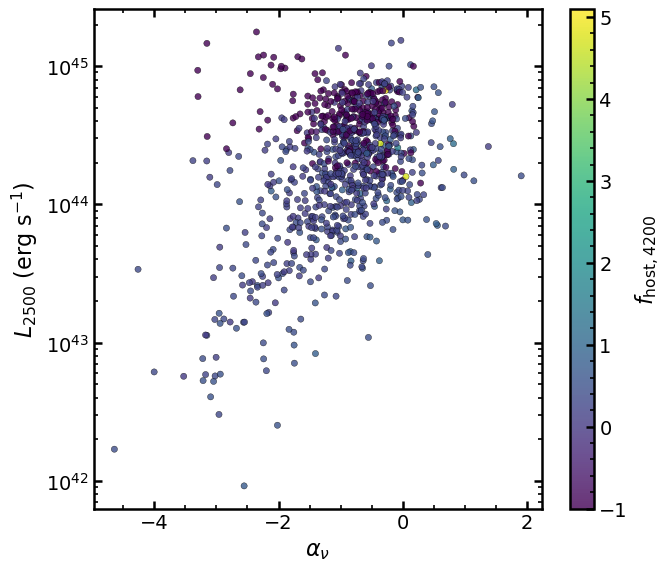

Saved plots/hubble/test/L2500_vs_alpha_nu.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np
import matplotlib.pyplot as plt
import os

def plot_L2500_vs_alpha_nu(df_agn, cosmo_model, z_pivot_agn,
                           plot_path='plots/hubble', show=False, debias=True, dms=None):
    d = df_agn.copy()

    # --- Build cosmology ---
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=70, Om0=0.3, w0=-1)   # set defaults if no posterior
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    else:
        raise ValueError("Add support for your cosmology model here")

    # --- Absolute magnitudes & debias ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
        M2500 -= dm_interp(pts)
    else:
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value

    logL2500 = -0.4 * (M2500 - 90.0)
    L2500 = 10**logL2500

    # --- Add computed L back into df for masking ---
    d = d.assign(L2500=L2500, logL2500=logL2500)

    # --- Now apply mask on f_host_4200 ---
    d = d[d['f_host_4200'] > -2].reset_index(drop=True)

    # --- Scatter plot ---
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(d['alpha_nu'], d['L2500'], c=d['f_host_4200'], cmap='viridis',
                    s=20, alpha=0.8, edgecolor='k', lw=0.3)

    cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
    cbar.set_label(r'$f_{\rm host,4200}$')

    ax.set_xlabel(r'$\alpha_\nu$')
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_yscale('log')

    plt.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    outfile = os.path.join(plot_path, "L2500_vs_alpha_nu.png")
    plt.savefig(outfile, dpi=300)
    if show:
        plt.show()
    plt.close()
    print(f"Saved {outfile}")

plot_L2500_vs_alpha_nu(df_agn, cosmo_model="FlatwCDM", z_pivot_agn=1.5, debias=True, dms=dmag_corr, show=True, plot_path='plots/hubble/test')